### Run DLC example
In this example we load data from our DLC observation logs to determine the offset positions of the star on the fiber to run. Then we run dlc_package to compute the expected velocities at each offset position

### Step 1. Import packages

In [1]:
import numpy as np
import matplotlib.pylab as plt
from pathlib import Path
import sys
import astropy.units as u

plt.ion()
# just for the notebook, can remove if running as a script
%matplotlib widget


# optional yaml file could feed
config_path = "/dlc_package/configs/gen_config.yaml"

file_path = '/Users/ashleybaker/Documents/DLC/'
sys.path.insert(0, str(Path(file_path) / "dlc_package"))
from obsdata_utils import cObsLog
from dlc import DifferentialLimbCoupling as dlc_class


### Step 2a. Load the Observation information
Use the observation log package (cObsLog) to load the observing logs and select the target and date of observations we want. 

In [4]:

############ PARAMS
target = 'MuGem'
date = '20250227'
data_path = f'../../_data/{target}/'
observation_log_file = str(Path(file_path, "_data/PARVIRVBiasObservationSummary.xlsx"))
##############

# Load MuGem Supporting Data - obslog
obslog = cObsLog(observation_log_file, data_path)
obslog.select_by_target(target)
obslog.select_by_date(date) # data stored in obslog.obs_data_subset 


warning, did not find file ../../_data/MuGem/ZetLeo_R01_20250227062615_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R01_20250227062929_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R02_20250227062929_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R03_20250227062929_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R01_20250227063648_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R02_20250227063648_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R03_20250227063648_deg0_sp.fits, setting BC and time to nan for this observation
warning, did not find file ../../_data/MuGem/ZetLeo_R01_2025022706431

### Step 2b. Format the Offsets
Edit the offsets to be in the units we need and defined relative to the center - this can be moved to the obs log package

In [24]:
# define x, y offsets. theta is unknown for now so run a few
guide_platescale = 36.7 # mas/pix, from guide camera analysis, should add to obsdata utils

# Here we modify the offsets to be relative to the center, 0,0 and to be in the right units for the DLC package (mas)
ifinite = np.where((obslog.obs_data_subset.xpos_meas > 0) & (obslog.obs_data_subset.ypos_meas > 0))[0] # check that all offsets are in the same quadrant, if not need to flip signs
xoffsets = guide_platescale * (obslog.obs_data_subset.xpos_meas[ifinite]) # found centers from plot, should really store this though
yoffsets = guide_platescale * (obslog.obs_data_subset.ypos_meas[ifinite])

mjds = obslog.obs_data_subset.weighted_times_bjd.values[ifinite]

icentered = np.where((obslog.obs_data_subset.xpos[ifinite] ==0) & (obslog.obs_data_subset.ypos[ifinite]==0))[0]
xcent = np.mean(obslog.obs_data_subset.xpos_meas[icentered])
ycent = np.mean(obslog.obs_data_subset.ypos_meas[icentered])

# pick a subset of offsets to run and convert to mas
xoffsets -= guide_platescale * xcent # mas/pix
yoffsets -= guide_platescale * ycent # mas/pix

# make these unique..
_, iunique = np.sort(np.unique(xoffsets,return_index=True)).astype(int) # unique offsets to run, should be 4 for the 4 quadrants, but check that they are all in the same quadrant first

In [25]:
print(iunique)

[  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  80  85  88
  91  94  97 100 103 106 109 112 115 118 121 124 127]


### Step 3. Run DLC
Now that we have the offsets we can run the DLC pacakge to determine the corresponding velocities expected for our system

In [28]:
# Start dlc simulation
dlcc = dlc_class(diagnostics_on=False, 
                 config=dict(xoffsets = xoffsets.values,
                             yoffsets = yoffsets.values,
                             theta=70 * u.deg, 
                             vsini=8.4 * u.km/u.s, 
                             R=70000, 
                             diameter=15.0 * u.mas,
                             telescope='Palomar'))

dlcc.run()


Loading /Users/ashleybaker/Documents/DLC/dlc_package/data/coupling_maps/staticModel_Keck_yJ_defoc0nmRMS_LO0nmRMS_Fnum3.67_atm0_adc0_nWvls10_PL0.fits
vel slope 0.09326725758 km / s
res vel 4282.7 m / s spec kernel wid 183676.4 m pix / km
Running x,y position 14.08584418920941 mas 8.531476930542965 mas
vel 0.02532963389034068 km / s
Running x,y position 14.08584418920941 mas 8.531476930542965 mas
vel 0.02532963389034068 km / s
Running x,y position 14.08584418920941 mas 8.531476930542965 mas
vel 0.02532963389034068 km / s
Running x,y position 14.08584418920941 mas 8.531476930542965 mas
vel 0.02532963389034068 km / s
Running x,y position 14.08584418920941 mas 8.531476930542965 mas
vel 0.02532963389034068 km / s
Running x,y position 28.443115485498424 mas 8.541169038736086 mas
vel -0.013584772356609808 km / s
Running x,y position 28.443115485498424 mas 8.541169038736086 mas
vel -0.013584772356609808 km / s
Running x,y position 28.443115485498424 mas 8.541169038736086 mas
vel -0.013584772356

### Step 4. Plot!
Lots of plots to make and save...

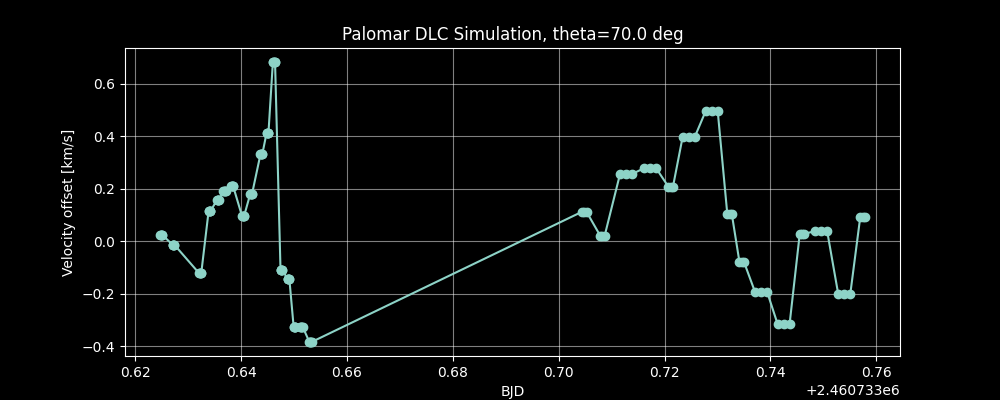

In [29]:
#dlcc.printSettings()
save_path = './'
file_name = f'{target}_{date}_DLC_simulation_theta{dlcc.theta.value}_vsini{dlcc.vsini.value}_R{dlcc.R}'

#dlcc.plot_star_fiber(save_path = save_path + file_name + '_star_fiber.png')
dlcc.plot_rvs(mjds, xlabel= 'BJD', save_path = save_path + file_name + '_rvs.png')

#dlcc.plot_lsf_ccf(save_path = save_path + file_name + '_lsf_ccf.png')


# Next Steps
- provide output path where will save the plots
- next feed it mu gem offsets and parameters, make a mugem config perhaps
- then add tt jitter
- then add DAR effects